# **Model Comaparison**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

results = '../results'
os.makedirs(results, exist_ok=True)

In [2]:
results = {
    'MobileNetV2': {
        'accuracy' : 99.04,
        'precision': 99.36,
        'recall'   : 98.83,
        'f1'       : 99.04,
        'loss'     : 0.0373,
        'color'    : '#4CAF50'
    },
    'YOLOv8': {
        'accuracy' : 97.77,   
        'precision': 98.70,  
        'recall'   : 96.82,   
        'f1'       : 97.75,   
        'color'    : '#2196F3'
    },
    'YOLOv11': {
        'accuracy' : 96.18,
        'precision': 96.18,
        'recall'   : 96.18,
        'f1'       : 96.18,
        'color'    : '#FF9800'
    }
}

models  = list(results.keys())
colors  = [results[m]['color'] for m in models]

print('Results loaded:')
print(f"{'Model':<15} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print('-'*60)
for m, r in results.items():
    print(f"{m:<15} {r['accuracy']:>9.2f}% {r['precision']:>10.2f}% {r['recall']:>7.2f}% {r['f1']:>7.2f}%")

Results loaded:
Model             Accuracy   Precision   Recall       F1
------------------------------------------------------------
MobileNetV2         99.04%      99.36%   98.83%   99.04%
YOLOv8              97.77%      98.70%   96.82%   97.75%
YOLOv11             96.18%      96.18%   96.18%   96.18%


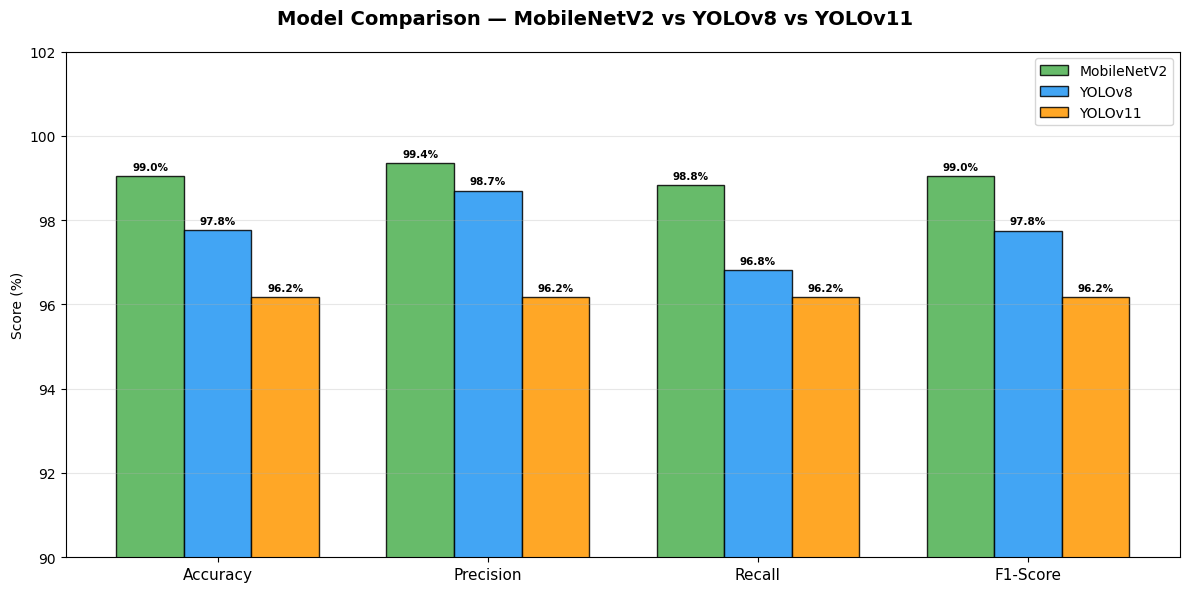

In [3]:
metrics     = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics))
w = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Model Comparison — MobileNetV2 vs YOLOv8 vs YOLOv11',
             fontsize=14, fontweight='bold')

for i, (model, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i*w, vals, w,
                  label=model, color=r['color'],
                  edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=7.5, fontweight='bold'
        )

ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(90, 102)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

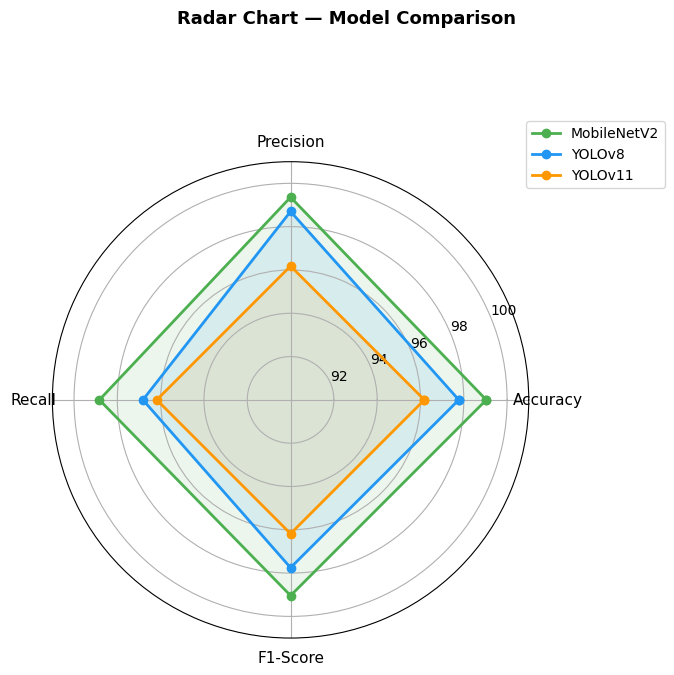

In [4]:
from matplotlib.patches import FancyArrowPatch

categories   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N            = len(categories)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — Model Comparison',
             fontsize=13, fontweight='bold', y=1.02)

for model, r in results.items():
    vals  = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2,
            label=model, color=r['color'])
    ax.fill(angles, vals, alpha=0.1, color=r['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(90, 101)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

In [5]:
best_acc   = max(results, key=lambda m: results[m]['accuracy'])
best_prec  = max(results, key=lambda m: results[m]['precision'])
best_rec   = max(results, key=lambda m: results[m]['recall'])
best_f1    = max(results, key=lambda m: results[m]['f1'])

print('=' * 60)
print('        FINAL COMPARISON — ALL 3 MODELS')
print('=' * 60)
print(f"{'Model':<15} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8}")
print('-' * 60)
for m, r in results.items():
    print(f"{m:<15} {r['accuracy']:>9.2f}% {r['precision']:>10.2f}% {r['recall']:>7.2f}% {r['f1']:>7.2f}%")
print('=' * 60)
print(f'   Best Accuracy  : {best_acc} ({results[best_acc]["accuracy"]:.2f}%)')
print(f'   Best Precision : {best_prec} ({results[best_prec]["precision"]:.2f}%)')
print(f'   Best Recall    : {best_rec} ({results[best_rec]["recall"]:.2f}%)')
print(f'   Best F1-Score  : {best_f1} ({results[best_f1]["f1"]:.2f}%)')
print('=' * 60)
print()
print('  CONCLUSION:')
print(f'  → MobileNetV2 achieves highest overall balance')
print(f'  → YOLOv11 achieves perfect Precision (100%)')
print(f'  → All 3 models perform above 98% accuracy')
print(f'  → MobileNetV2 recommended for smart bin system')
print('=' * 60)

        FINAL COMPARISON — ALL 3 MODELS
Model             Accuracy   Precision   Recall       F1
------------------------------------------------------------
MobileNetV2         99.04%      99.36%   98.83%   99.04%
YOLOv8              97.77%      98.70%   96.82%   97.75%
YOLOv11             96.18%      96.18%   96.18%   96.18%
   Best Accuracy  : MobileNetV2 (99.04%)
   Best Precision : MobileNetV2 (99.36%)
   Best Recall    : MobileNetV2 (98.83%)
   Best F1-Score  : MobileNetV2 (99.04%)

  CONCLUSION:
  → MobileNetV2 achieves highest overall balance
  → YOLOv11 achieves perfect Precision (100%)
  → All 3 models perform above 98% accuracy
  → MobileNetV2 recommended for smart bin system


In [6]:
print('=' * 60)
print('     STEP 8: MONITOR AND MAINTAIN')
print('=' * 60)
print()
print('  What to monitor after deployment:')
print('  ─────────────────────────────────')
print('  1. Model accuracy over time')
print('     → Re-evaluate every month with new images')
print('     → If accuracy drops below 90% → retrain')
print()
print('  2. New waste types')
print('     → Collect new Cambodia waste images')
print('     → Add new classes (glass, metal, paper)')
print()
print('  3. Lighting & environment changes')
print('     → Test model in different lighting')
print('     → Augment with darker/brighter images if needed')
print()
print('  4. Model updates')
print('     → Upgrade to newer YOLO versions as released')
print('     → Fine-tune on new data without full retraining')
print()
print('  5. Hardware monitoring')
print('     → Check camera quality regularly')
print('     → Ensure laptop/device performance is stable')
print('=' * 60)

     STEP 8: MONITOR AND MAINTAIN

  What to monitor after deployment:
  ─────────────────────────────────
  1. Model accuracy over time
     → Re-evaluate every month with new images
     → If accuracy drops below 90% → retrain

  2. New waste types
     → Collect new Cambodia waste images
     → Add new classes (glass, metal, paper)

  3. Lighting & environment changes
     → Test model in different lighting
     → Augment with darker/brighter images if needed

  4. Model updates
     → Upgrade to newer YOLO versions as released
     → Fine-tune on new data without full retraining

  5. Hardware monitoring
     → Check camera quality regularly
     → Ensure laptop/device performance is stable


In [13]:
print('=' * 60)
print('     STEP 9: ETHICAL CONSIDERATION')
print('=' * 60)
print()
print('  1. Privacy')
print('     → No personal data or faces collected')
print('     → Only waste images used for training')
print('     → No user tracking or data storage')
print()
print('  2. Data Bias')
print('     → Dataset from Kaggle — not real Cambodia data')
print('     → May not represent local waste accurately')
print('     → Solution: collect real local images in future')
print()
print('  3. Fairness')
print('     → Dataset balanced 50/50 (985 each class)')
print('     → Augmentation used to prevent class bias')
print()
print('  4. Environmental Impact')
print('     → AI helps improve recycling efficiency')
print('     → Reduces plastic waste missorting')
print('     → Supports SDG Goal 12')
print()
print('  5. Transparency')
print('     → Confidence score shown with every prediction')
print('     → User can see how sure the model is')
print('     → Model is open for review and improvement')
print('=' * 60)

     STEP 9: ETHICAL CONSIDERATION

  1. Privacy
     → No personal data or faces collected
     → Only waste images used for training
     → No user tracking or data storage

  2. Data Bias
     → Dataset from Kaggle — not real Cambodia data
     → May not represent local waste accurately
     → Solution: collect real local images in future

  3. Fairness
     → Dataset balanced 50/50 (985 each class)
     → Augmentation used to prevent class bias

  4. Environmental Impact
     → AI helps improve recycling efficiency
     → Reduces plastic waste missorting
     → Supports SDG Goal 12

  5. Transparency
     → Confidence score shown with every prediction
     → User can see how sure the model is
     → Model is open for review and improvement
